In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bank-marketing/bankmarketing.csv


# K modes
### ML lab 6
Yasir Ahmad  
22MIA1064

In [2]:
!pip install kneed

In [3]:
data_1 = pd.read_csv("/kaggle/input/bank-marketing/bankmarketing.csv")
data_1.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Select the first 100 rows and specific columns
data1 = data_1.loc[:499, ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week']]
data1.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon
1,57,services,married,high.school,unknown,no,no,telephone,may,mon
2,37,services,married,high.school,no,yes,no,telephone,may,mon
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon
4,56,services,married,high.school,no,no,yes,telephone,may,mon


In [5]:
print(data1.shape)
print(data1.dtypes)
print(data1.columns)

(500, 10)
age             int64
job            object
marital        object
education      object
default        object
housing        object
loan           object
contact        object
month          object
day_of_week    object
dtype: object
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week'],
      dtype='object')


In [6]:
from sklearn.preprocessing import LabelEncoder

df = data1
# Convert numerical 'age' to binned categories
df['age_bin'] = pd.cut(df['age'],
                       bins=[0, 20, 30, 40, 50, 60, 70, 80, 90, 100],
                       labels=['0-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100'])

# Drop the original 'age' column as we are using 'age_bin'
df = df.drop(columns=['age'])

# Convert categorical columns to numerical using LabelEncoder
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [7]:
print(df.shape)
print(df.dtypes)
df.head()

(500, 10)
job            int64
marital        int64
education      int64
default        int64
housing        int64
loan           int64
contact        int64
month          int64
day_of_week    int64
age_bin        int64
dtype: object


,job,marital,education,default,housing,loan,contact,month,day_of_week,age_bin
0,3,1,0,0,0,0,0,0,0,3
1,7,1,3,1,0,0,0,0,0,3
2,7,1,3,0,2,0,0,0,0,1
3,0,1,1,0,0,0,0,0,0,1
4,7,1,3,0,0,2,0,0,0,3


## Optimal K using Elbow Method

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 1878.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 1878.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 1878.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 1878.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 1878.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 92, cost: 1612.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 62, cost: 1688.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...


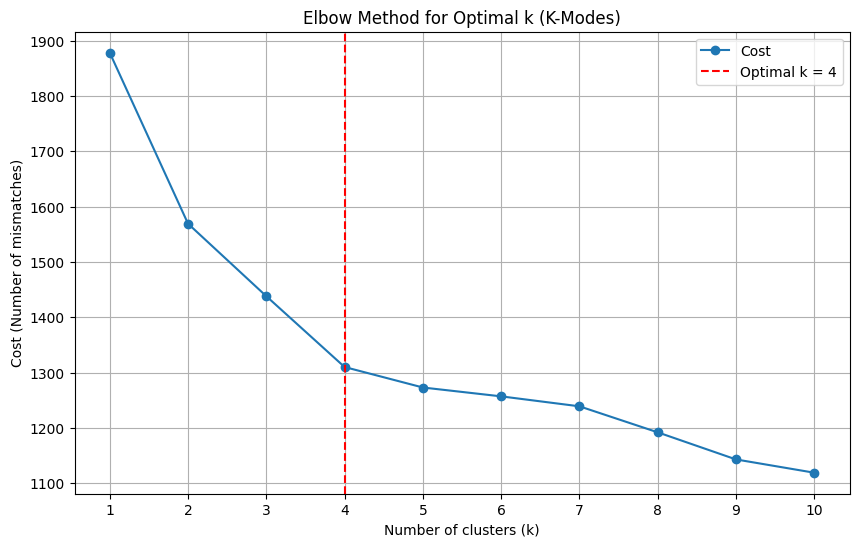

The optimal number of clusters (k) is: 4


In [8]:
import matplotlib.pyplot as plt
from kmodes.kmodes import KModes
from kneed import KneeLocator
import pandas as pd

def elbow_method_kmodes_knee(df, max_k=10):
    """
    Use the Elbow Method with Knee detection to find the optimal number of clusters for K-Modes.

    Parameters:
    - df (pandas DataFrame): The dataset to cluster.
    - max_k (int): The maximum number of clusters to evaluate.

    Returns:
    - best_k (int): The optimal number of clusters based on the knee point.
    """
    costs = []

    # Iterate over a range of k values (from 1 to max_k)
    for k in range(1, max_k + 1):
        km = KModes(n_clusters=k, init='Huang', n_init=5, verbose=1)
        clusters = km.fit_predict(df)
        costs.append(km.cost_)  # The cost function value for K-Modes

    # Use kneed to find the knee point
    kn = KneeLocator(range(1, max_k + 1), costs, curve='convex', direction='decreasing')
    best_k = kn.knee

    # Plot the cost values with the dotted line for optimal k
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k + 1), costs, marker='o', label='Cost')
    plt.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal k = {best_k}')
    plt.title('Elbow Method for Optimal k (K-Modes)')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Cost (Number of mismatches)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"The optimal number of clusters (k) is: {best_k}")

    return best_k

# Example usage with your DataFrame 'df'
best_k = elbow_method_kmodes_knee(df, max_k=10)


## kModes Implementation

In [9]:
import pandas as pd
from kmodes.kmodes import KModes
import numpy as np

def kmodes_clustering(df, n_clusters):
    """
    Perform K-Modes clustering on the customer clustering dataset
    using Hamming Distance.

    Parameters:
    - df (pandas DataFrame): customer clustering dataset
    - n_clusters (int): number of clusters

    Returns:
    - centroids (numpy array): final centroids
    - labels (numpy array): cluster labels for each data point
    """
    # Initialize K-Modes clustering object with Hamming Distance
    km = KModes(n_clusters=n_clusters, init='Huang', cat_dissim=lambda a, b, **kwargs: np.sum(a != b, axis=1))

    # Perform K-Modes clustering
    km.fit(df)

    # Print centroids after each iteration
    for i in range(km.n_iter_):
        print(f"Iteration {i+1}:")
        print(km.cluster_centroids_)
        print()

    # Get final centroids and labels
    centroids = km.cluster_centroids_
    labels = km.labels_

    return centroids, labels


# Perform K-Modes clustering
centroids, labels = kmodes_clustering(df, n_clusters=best_k)

# Print final centroids and labels
print("Final Centroids:")
print(centroids)

print("\nCluster Labels:")
df['cluster'] = labels
df.head()

Iteration 1:
[[0 1 2 0 0 0 0 0 1 1]
 [1 1 6 1 0 0 0 0 0 2]
 [4 1 5 0 0 0 0 0 0 3]
 [0 1 3 0 2 0 0 0 0 1]]

Iteration 2:
[[0 1 2 0 0 0 0 0 1 1]
 [1 1 6 1 0 0 0 0 0 2]
 [4 1 5 0 0 0 0 0 0 3]
 [0 1 3 0 2 0 0 0 0 1]]

Final Centroids:
[[0 1 2 0 0 0 0 0 1 1]
 [1 1 6 1 0 0 0 0 0 2]
 [4 1 5 0 0 0 0 0 0 3]
 [0 1 3 0 2 0 0 0 0 1]]

Cluster Labels:


,job,marital,education,default,housing,loan,contact,month,day_of_week,age_bin,cluster
0,3,1,0,0,0,0,0,0,0,3,2
1,7,1,3,1,0,0,0,0,0,3,1
2,7,1,3,0,2,0,0,0,0,1,3
3,0,1,1,0,0,0,0,0,0,1,0
4,7,1,3,0,0,2,0,0,0,3,2
